# Project: Data-driven Insights using Python: FoodHub Data Analysis



# Problem Statement

## Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. An online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub, offers access to multiple restaurants through a single smartphone app.
The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirm the pick-up in the app and travel to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.



## Objective

The food aggregator company has stored the data of the different orders made by the registered customers in its online portal. They want to analyze the data to get a fair idea about the demand for different restaurants, which will help them enhance their customer experience. Suppose you are hired as a Data Scientist in this company, and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company improve its business.

## Data Description

The data contains different data related to a food order. The detailed data dictionary is given below.

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

# Let us start by importing the required libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 -q --user

  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [ ]:
# Import libraries for data manipulation
import numpy as np
import pandas as pd

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Understanding the structure of the data

In [ ]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Write your code here to read the data
file_path = "/content/drive/MyDrive/UT Austin/foodhub_order (1).csv"
data = pd.read_csv(file_path)

In [ ]:
# copying data to another variable to avoid any changes to original data
df = data.copy()

In [ ]:
# Write your code here to view the first 5 rows
# check if there is something weird in data
# weird- rating: has not-given
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
# Check number of rows and columns
df.shape

(1898, 9)

#### Observations: It has 1898 rows and 9 columns


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
# Check the datatypes of columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:


1.   order_id, customer_id, food_preparation_time, and delivery_time  are integer variables. Among them, food_preparation_time and delivery_time are numerical variables representing time in minutes.
2.   restaurant_name, cuisine_type, day_of_the_week, and rating are categorical (object) variables.
3. cost_of_the_order is a floating variable, which is a continuous numerical variable.
4. **Rating is shown as an object type, which means that there may be some missing values that are written in words.**





In [ ]:
# investigate the rating column (1)- check the unique values

df['rating'].unique()

array(['Not given', '5', '3', '4'], dtype=object)

In [ ]:
df['rating'].value_counts(normalize=True)

,proportion
rating,
Not given,0.387777
5,0.309800
4,0.203372
3,0.099052


##Obervations:
Since there is a huge proportion of users who didn't rate, it would be not appropriate to use mean or median for these ratings or even to delete these rows. I could categorize these "Not given" users as a group in the analysis.

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
# Check for missing values (Only check for NaN, but not something like Not Given)
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### Observations:



There is no missing value in the data frame. As I said before, I would treate **"Not Given"** as a value in the rating column.

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
# Statistical summary of the data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.0,1.477496e+06,548.049724,1476547.00,1477021.25,1477495.50,1.477970e+06,1478444.00
customer_id,1898.0,1.711685e+05,113698.139743,1311.00,77787.75,128600.00,2.705250e+05,405334.00
cost_of_the_order,1898.0,1.649885e+01,7.483812,4.47,12.08,14.14,2.229750e+01,35.41
food_preparation_time,1898.0,2.737197e+01,4.632481,20.00,23.00,27.00,3.100000e+01,35.00
delivery_time,1898.0,2.416175e+01,4.972637,15.00,20.00,25.00,2.800000e+01,33.00


#### Observations:
1. The minimum food preparation time is 20 minutes.
2. The average food preparation time is approximately 27 minutes.
3. The maximum food preparation time is 35 minutes.
4. From above, we can say that the food preparation times are relatively consistent across orders.


### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
df['rating'].value_counts()

,count
rating,
Not given,736
5,588
4,386
3,188


#### Observations:
There are 736 (out of 1898) customers, and that means that a significant portion of users choose not to rate their orders.


# Exploratory Data Analysis (EDA)

## Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

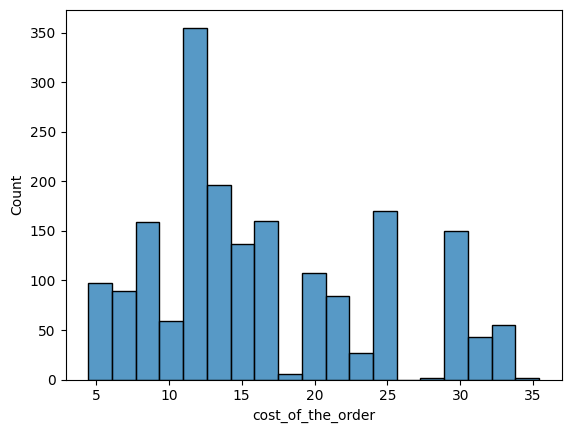

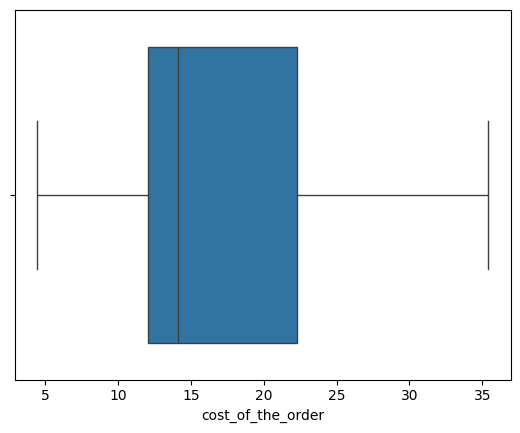

In [ ]:
# cost_of_the_order
sns.histplot(data=df,x='cost_of_the_order')
plt.show()
sns.boxplot(data=df,x='cost_of_the_order')
plt.show()

## Observations:
 1. Most orders fall within a moderate price range, and there is no outlier.
 2. The most-frequent cost of the orders falls between 11-13.

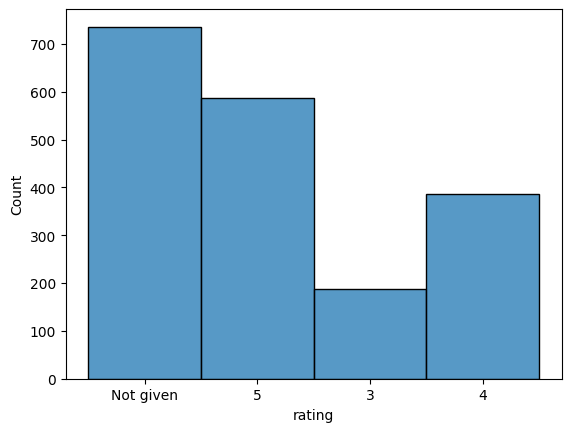

In [ ]:
# rating
sns.histplot(data=df,x='rating')
plt.show()


Observations:

Second to the "Not-given", 5-star-rating orders are the most frequent according to the plots. This means that a high proportion of customers are satisfied with their orders. But I would still investigate the customers who didn't give rating and to find out why they didn't.

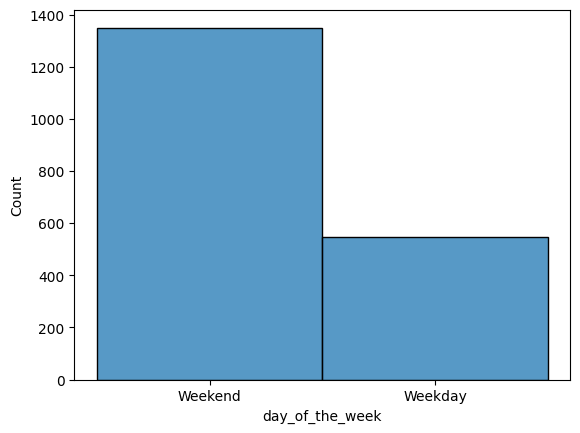

,proportion
day_of_the_week,
Weekend,0.711802
Weekday,0.288198


In [ ]:
# day of the week
sns.histplot(data=df,x='day_of_the_week')
plt.show()

# calculate the percentage
percent_day_of_the_week=df['day_of_the_week'].value_counts(normalize=True)
percent_day_of_the_week

Observations:

71% of the orders were made on weekend, and only 29% of the orders were made on weekday.

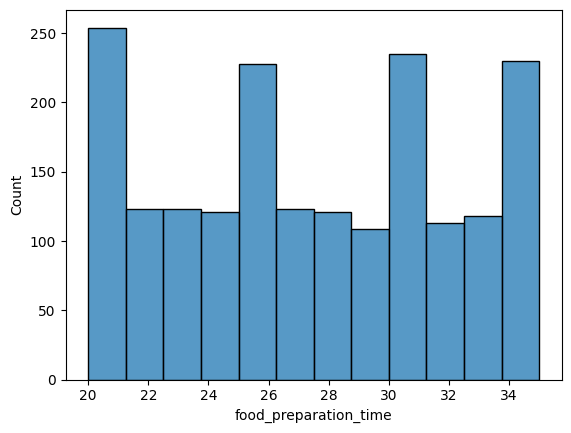

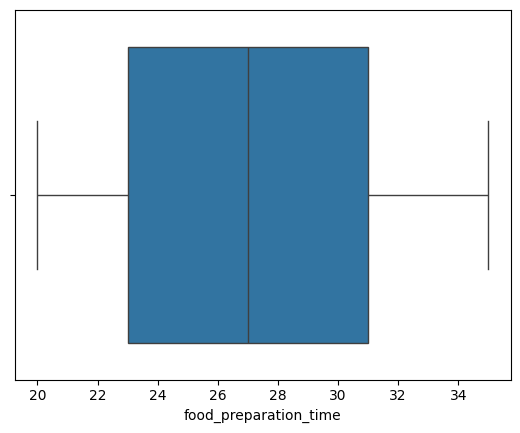

In [ ]:
# food_preparation_time
sns.histplot(data=df,x='food_preparation_time')
plt.show()
sns.boxplot(data=df,x='food_preparation_time')
plt.show()

Observations:

1.The distribution appears fairly symmetric without extreme skewness, and we can also see from the boxplot that there is no outlier, suggesting that the preparation time are stable across orders.
2. The median preparation time falls around 27-28 minutes, which aligns closely with the average value.

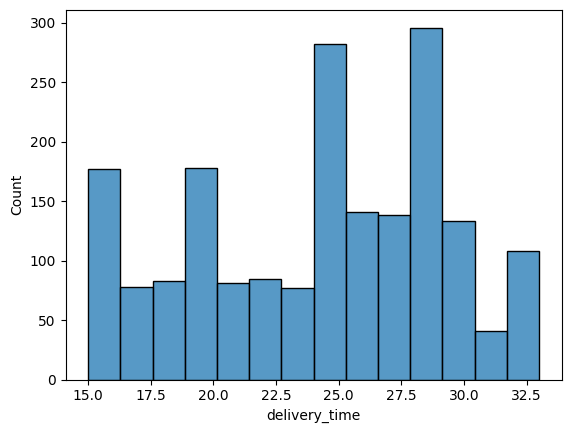

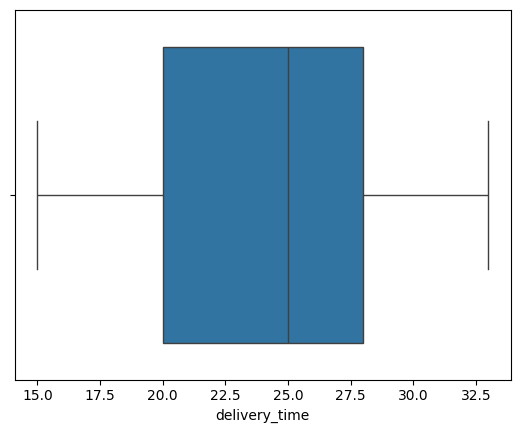

In [ ]:
# delivery_time
sns.histplot(data=df,x='delivery_time')
plt.show()
sns.boxplot(data=df,x='delivery_time')
plt.show()

Observations:

1. Most deliveries are concentrated between 20 and 30 minutes, indicating moderate consistency in delivery duration.
2. The distribution seems to be no strong skewness and there is no outlier in the boxplot, meaning that the delivery times are relatively stable.
3. The median delivery time is around 25 minutes, which is close to the average.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:
df['restaurant_name'].value_counts().head(5)

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:

No.1 is “Shake Shack", 219 orders
No.2 is "The Meatbal Shop", 132 orders. There is a huge gap between No.1 and No.2.
No.3 is "Blue Ribbon Sushi", 119 orders.
No.4 is " Blue Ribbon Fried Chicken", 96 orders.
No.5 is " Parm", 68 orders.



### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
# Filter weekend orders
weekend_orders= df[df['day_of_the_week']=='Weekend']
#count cousins
weekend_orders['cuisine_type'].value_counts().head(3)

,count
cuisine_type,
American,415
Japanese,335
Italian,207


#### Observations: The most popular cuisines on weekends are : American, 415 orders, Japanese, 335 orders, and Italian , 207 orders.


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
# Total number of orders
total_orders= len(df['cost_of_the_order'])

# orders above 20
orders_above_20= len(df[df['cost_of_the_order']>20])

# calculate percentage
percentage_above_20=(orders_above_20/total_orders)*100
percentage_above_20

29.24130663856691

#### Observations:
Approximately 29% of the orders cost more than 20 dollars.
This means that a significant portion of orders fall into a lower price range.


### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
# calculate the mean of delivery time
average_delivery_time=round(df['delivery_time'].mean(),2)
average_delivery_time

np.float64(24.16)

#### Observations: On average, customers take around 24 minutes to receive their orders.This means that most deliveries are generally efficient.


### **Question 11:** The company has decided to give 20% discount vouchers to the top 5 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
# use value count
top_frequent_customers= df['customer_id'].value_counts().head(5)
top_frequent_customers

,count
customer_id,
52832,13
47440,10
83287,9
250494,8
259341,7


#### Observations:
According to the analysis, customer id:52832, 47740, 83287,250494, and 259341 contributed significantly to repeat business. They may be valueable targets for discounts and other promotional incentives.

## Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset and provide observations. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


### (1) How are the correlations between them?

In [ ]:
# Replace Not given and convert it to numeric
df['rating']=df['rating'].replace('Not given', np.nan)
df['rating']=pd.to_numeric(df['rating'])

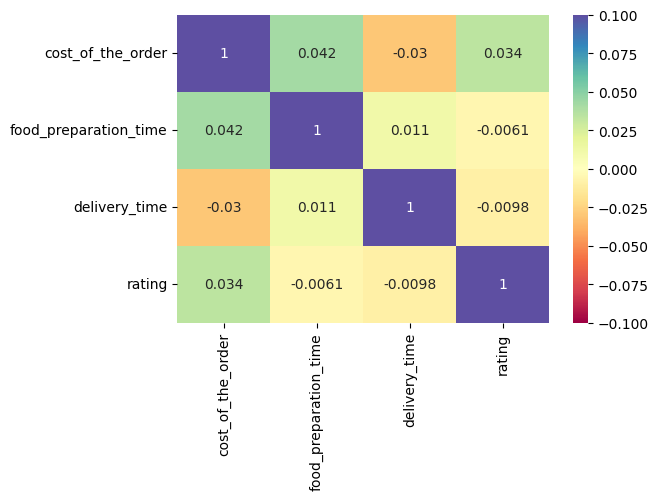

In [ ]:
# plot correlation map for only numerical and categorical columns

plt.figure(figsize=(6,4))
sns.heatmap(df[['cost_of_the_order','food_preparation_time', 'delivery_time','rating']].corr(),
            annot=True, cmap= 'Spectral',vmin=-0.1,vmax=0.1)
plt.show()

### Observations:
There is no strong linear relationship between any of the numerical variables. Surprisingly, there are no strong negative relationships between food preparation time and delivery time vs rating.

###(2) Delivery time vs day type

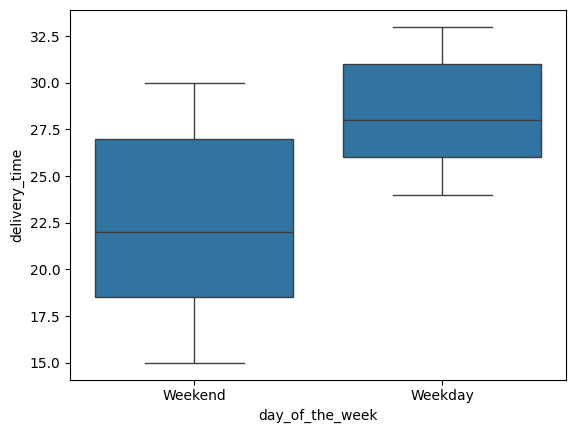

In [ ]:
sns.boxplot(data=df, x='day_of_the_week', y='delivery_time')
plt.show()

##Observations:
The delivery time for orders in weekdays are way higher than the ones occurs on weekends. The median delivery time for weekday is around
27.5 minutes, comparing with the median delivery time for weekend is around 22 minutes.

###(3) Delivery time vs rating

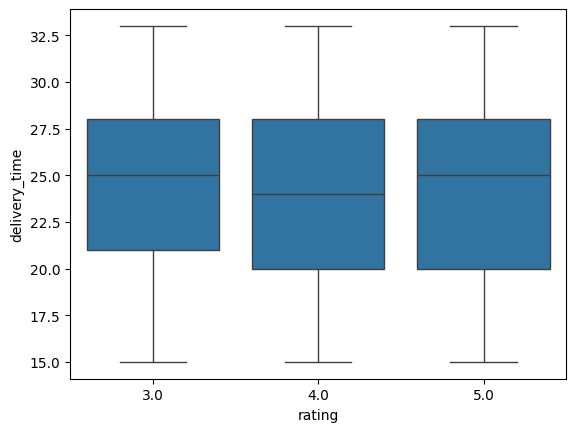

In [ ]:
sns.boxplot(data=df, x= 'rating', y='delivery_time')
plt.show()

### Observations:

While we think that the lower delivery time is, the higher rating will be, the plot doesn't show in this trend. According to my analysis, there is no much difference in the delivery time among these ratings. Therefore, we can say that the delivery time is not one of the key factors that influence the rating.

###(4) day of the week and cost of the order and rating

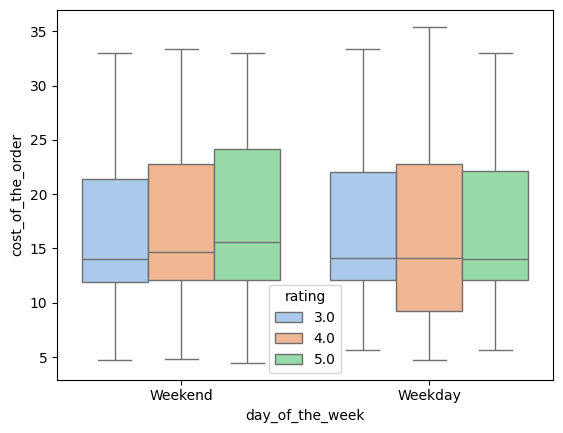

In [ ]:
sns.boxplot(data=df, x='day_of_the_week', y='cost_of_the_order', hue='rating', palette= 'pastel')
plt.show()

### Observations:
There is no relationship between cost of the order and rating.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
# Step 1: Calculate rating count and average rating
restaurant_summary = df.groupby('restaurant_name')['rating'].agg(['count', 'mean'])

# Step 2: Filter based on conditions
eligible_restaurants = restaurant_summary[
    (restaurant_summary['count'] > 50) &
    (restaurant_summary['mean'] > 4)
]

# Step 3: Display result
eligible_restaurants

,count,mean
restaurant_name,,
Blue Ribbon Fried Chicken,64,4.328125
Blue Ribbon Sushi,73,4.219178
Shake Shack,133,4.278195
The Meatball Shop,84,4.511905


#### Observations:
According to the analysis, only Blue Ribbon Fried Chicken, Blue Ribbon Sushi,Shake Shack, and The Meatball Shop these 4 restaurants are eligible to receive promotional offers.


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
# create the commission column
df['commission']=0.0

# Apply 25% for cost >20
df.loc[df['cost_of_the_order']>20, 'commission']=df['cost_of_the_order']*0.25

# Apply 15% for cost >5
df.loc[(df['cost_of_the_order']>5) & (df['cost_of_the_order']<=20), 'commission' ]=df['cost_of_the_order']*0.15

# Sum up the revenue
total_revenue=df['commission'].sum()

total_revenue

np.float64(6166.303)

#### Observations: The net revenue received by company is 6166.303 dollars.


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
# create a total time column
df['total time']=df['food_preparation_time']+df['delivery_time']

# count the orders >60 minutes
orders_more_than_60= df[df['total time']>60].shape[0]

# count the total order
total_order=df.shape[0]

# count the percentage
percentage= orders_more_than_60/total_order*100
percentage

10.537407797681771

#### Observations:
Approximately 10.54% of the orders take more than 60 minutes from order placement to delivery.

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [ ]:
# calculate mean delivery time by grouping by days

mean_delivery_time=df.groupby('day_of_the_week')['delivery_time'].mean()
mean_delivery_time

,delivery_time
day_of_the_week,
Weekday,28.340037
Weekend,22.470022


#### Observations:
There are two ways to do this analysis. First, you can see the boxplot (2) that I did previous for delivery time and day time. In this question, I used groupby to calculate average time of delivery separately for weekdays and weekends. And the result is consistent with the previous one: On average, the delivery time on weekends is 5-6 minutes faster than on weekdays.

# Conclusion and Business Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

In [ ]:
cuisine_summary=df.groupby('cuisine_type')['rating'].agg(['count','mean'])
cuisine_summary.sort_values(by='mean',ascending= False)

,count,mean
cuisine_type,,
Spanish,6,4.833333
Thai,9,4.666667
Indian,50,4.540000
Mexican,48,4.416667
Japanese,273,4.373626
Italian,172,4.360465
Chinese,133,4.338346
Southern,13,4.307692
French,10,4.300000


### Observations:

According to the cuisine types, Spanish and Thai dishes have the highest ratings, but there were not a lot of orders for these two dishes so continuous observation for these two dishes is needed. The indian cuisine has high rating and 50 ratings, which is more reliable in satisfying customers comparing with the previous two. Japanese, Italian,Chinese, and American dishes have highest order volumes, even though their ratings are lower, but they are consistently above 4. Therefore, we can conclude that Japanese, Italian, and Chinese dishes are the core revenue drivers in this case.

## Conclusions

This analysis provides key insights into customer behavior, restaurant performance, and revenue generation for the FoodHub system.

From the revenue's perspective, the results show that the company generates higher income from the orders above $20 due to higher comission rate, highlighting the importance of promoting premium orders.

From the operation's perspective, the food preparation time and delivery time have consistenly falled between 20 and 30 minutes. Considering only around 10% of orders exceeding 60 minutes to arrive in customers' hands, I would say that the general logistic system is considered efficient. However, it is worthy noting that the delivery time for weekday is 5-6 minutes higher than it is for weekend. I would investigate more to see the cause of higher delivery cost and if it is possible to lower it.

From the view of the type of cuisine and revenue, we can see that Japanese, Italian, Chinese, and American cuisines are strong contributors for the business with strong ratings. However, we might want to promote more Indian food because it has higher rating than these three and a fair volume of orders.


## Business Recommendations



1.   Use promotional activities to encourage higher-valued orders to increase commission revenue.
2.   Monitor the logistic system to make sure that the delivery time remain stable and find out more efficient ways to reduce the delivery time on weekdays.
3.  Raise promotional campaigns on high-volume, high-rated cuisines, such as Indian, Japanese, Italian, Chinese, and American cuisines.
4.   Concentrate on most of the promotional and marketing activites on weekends to be more efficient since 71% of orders occurred on weekends.

